In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## Задача 1

Необходимо сделать:

1) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

2) Рассчитать основные статистики для категориальных данных с помощью функции describe().

3) На экран вывести результат в виде таблицы DataFrame. Индексами сделать названия факторов.

In [ ]:
PATH_OUT = r'C:\Users\Dell\Desktop\MyPython\Yandex.Practica\ПРЕДЛОЖЕНИЯ\Школьники\Работа_над_материалами\Тема_2'

In [ ]:
df1 = pd.read_csv('market.csv',sep=',', encoding='cp1251', skipinitialspace=True)
df = df1.dropna()  # удалили строки с пропусками
df.shape

(1300, 14)

In [ ]:
df.head(3)

,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Выручка_от_клиента_текущий_месяц,Разность_выручки_тек_прошлый_месяц,Ошибка_сервиса,Страниц_за_визит,Всего_минут_текущем_месяце,Всего_минут_предыдущий_месяц
0,Снизилась,стандарт,да,2,717,0.22,Техника для красоты и здоровья,2,4425,-605,1,5,14,13
1,Снизилась,стандарт,да,2,917,0.99,Домашний текстиль,3,4472,-496,2,5,12,10
2,Снизилась,стандарт,нет,3,369,0.24,Мелкая бытовая техника и электроника,1,4826,-421,1,5,13,8


In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   покупательская_активность            1300 non-null   object 
 1   тип_сервиса                          1300 non-null   object 
 2   разрешить_сообщать                   1300 non-null   object 
 3   маркет_актив_6_мес                   1300 non-null   int64  
 4   длительность                         1300 non-null   int64  
 5   акционные_покупки                    1300 non-null   float64
 6   популярная_категория                 1300 non-null   object 
 7   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 8   выручка_от_клиента_текущий_месяц     1300 non-null   int64  
 9   разность_выручки_тек_прошлый_месяц   1300 non-null   int64  
 10  ошибка_сервиса                       1300 non-null   int64  
 11  страниц_за_визит              

                          count unique               top freq
покупательская_активность  1300      2   Прежний уровень  900
тип_сервиса                1300      2          стандарт  916
разрешить_сообщать         1300      2                да  967
популярная_категория       1300      6  Товары для детей  267


### дополнительные инструменты

In [ ]:
coumns_cat = df.select_dtypes(include=[object]).columns

In [ ]:
coumns_cat

Index(['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'популярная_категория', 'акция_доля'],
      dtype='object')

In [ ]:
df.select_dtypes(exclude=[object]).head(3)

,маркет_актив_6_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,выручка_от_клиента_текущий_месяц,разность_выручки_тек_прошлый_месяц,ошибка_сервиса,страниц_за_визит,всего_минут_текущем_месяце,всего_минут_предыдущий_месяц
0,2,717,0.22,2,4425,-605,1,5,14,13
1,2,917,0.99,3,4472,-496,2,5,12,10
2,3,369,0.24,1,4826,-421,1,5,13,8


## Задача 2

Необходимо сделать:


1) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

3) Рассчитать основные статистики для фактора "разность_выручки_тек_прошлый_месяц" с помощью функции describe(). При этом расчёт произвести по группам фактора "покупательская_активность."

3) На экран вывести результат в виде таблицы DataFrame. Перевести в целочисленный тип.

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
new_df = df.groupby('покупательская_активность')['разность_выручки_тек_прошлый_месяц'].describe().astype('int64')
print(new_df)

                           count  mean  std   min  25%  50%  75%  max
покупательская_активность                                            
Прежний уровень              900  -111  360 -1013 -377 -107  151  698
Снизилась                    400  -497  321 -1378 -726 -503 -272  265


In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
new_df = df.describe(include=[object]).T
print(new_df)

                          count unique               top freq
покупательская_активность  1300      2   Прежний уровень  900
тип_сервиса                1300      2          стандарт  916
разрешить_сообщать         1300      2                да  967
популярная_категория       1300      6  Товары для детей  267


## Задача 3

Необходимо:
1) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

2) Построить простую гистограмму, не изменяя настройки по умолчанию, по столбцу, название которого вводится. Гарантируется, что будет введено название столбца с числовым типом.
Сохраните гистограмму в файл target_2_3.png.

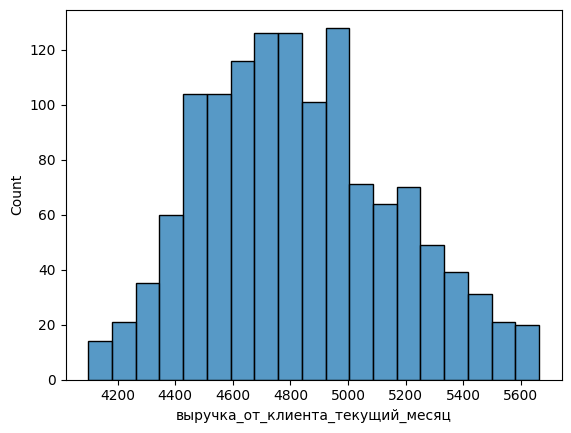

In [ ]:
sns.histplot(df['выручка_от_клиента_текущий_месяц'])
plt.savefig('target_2_3.png')
plt.show()

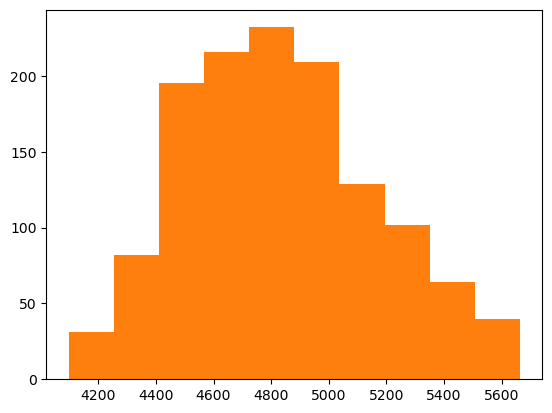

In [ ]:
plt.hist(df['выручка_от_клиента_текущий_месяц'])
plt.show()

### Задача 4

Необходимо:
1) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

2) Построить график плотности вероятности для факторов в количественной шкале с использованием библиотеки seaborn. При построении учесть:

построить график по столбцу, название которого вводится
на одном графике строить плотности вероятности по каждой группе из фактора покупательская_активность
Настроить только один параметр: наличие цветности под кривой плотности. А сами цвета - оставить по умолчанию

Сохраните гистограмму в файл target_2_4.png.

выручка_от_клиента_текущий_месяц


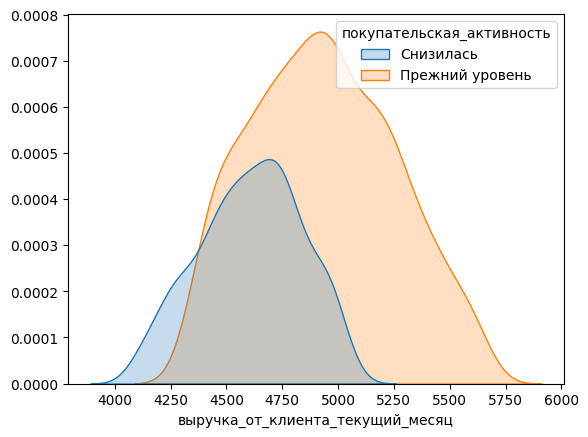

In [ ]:
col = input()
sns.kdeplot(df, x=col, hue="покупательская_активность", fill=True)
plt.ylabel('')
plt.savefig('target_2_4.png')
plt.show()

### Задача 5

Необходимо:
1) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

2) Построить график круговой диаграммы для факторов в категориальной шкале. При построении учесть:

построить график по столбцу, название которого вводится
доли категорий вывести на графике в формате процента с одним знаком после запятой
на графике вывести название категорий
остальные параметры оставить по умолчанию

Сохраните диаграмму в файл target_2_5.png.

In [ ]:
df = pd.read_csv(PATH_OUT + '\\market_csv.csv',sep=',', encoding='cp1251', skipinitialspace=True)

покупательская_активность


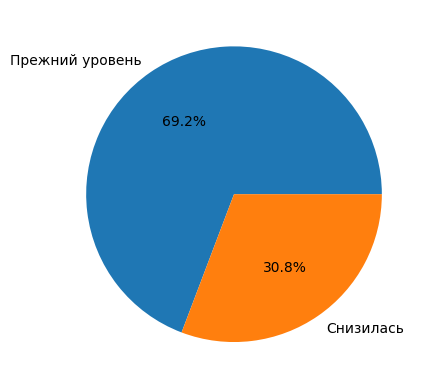

In [ ]:
col = input()
y = df[col].value_counts()
plt.pie(y, autopct='%1.1f%%', labels=y.index)
plt.savefig('target_2_5.png')
plt.show()

## Задача 6

В этой задаче необходимо сделать:

1) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

3) Создать новую категориальную переменную категории_товаров на основе фактора популярная_категория

- Товары для детей обозначить как покупки для детей
- Домашний текстиль, Кухонная посуда, Мелкая бытовая техника и электроника обозначить как покупки для быта
- Косметика и аксессуары , Техника для красоты и здоровья обозначить как покупки для себя

4) Сформировать новый датасет, в котором будут только клиенты, совершившие покупки для быта

5) Рассчитать основные статистики для фактора "разность_выручки_тек_прошлый_месяц" с помощью функции describe(). При этом расчёт произвести группам покупательская_активность

6) Перевести в целочисленный тип. На экран вывести результат в виде таблицы DataFrame.

In [ ]:
def f(x):
  if x == 'Товары для детей':
    return 'покупки для детей'
  elif x in ['Домашний текстиль', 'Кухонная посуда', 'Мелкая бытовая техника и электроника']:
    return 'покупки для быта'
  else:
    return 'покупки для себя'
df['категории_товаров'] = [f(x) for x in df['популярная_категория']]
df_new = df[df['категории_товаров'] == 'покупки для быта']
ans = df_new.groupby('покупательская_активность')['разность_выручки_тек_прошлый_месяц'].describe().astype('int64')
print(ans)

                           count  mean  std   min  25%  50%  75%  max
покупательская_активность                                            
Прежний уровень              413   -97  356 -1000 -356 -104  151  684
Снизилась                    212  -492  328 -1378 -724 -485 -261  265
